In [43]:
import pandas as pd
import ast
import matplotlib.pyplot as plt
from datasets import load_dataset
dataset=load_dataset('lukebarousse/data_jobs')
df=dataset['train'].to_pandas()
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills']=df['job_skills'].apply(lambda x:ast.literal_eval(x) if pd.notna(x) else x)

In [64]:
df_DA=df[df['job_title_short']=='Data Analyst'].copy()
df_DA['job_posted_month_no']=df_DA['job_posted_date'].dt.month.copy()

In [65]:
df_DA_exploded=df_DA.explode('job_skills')

In [68]:
df_DA_pivot=df_DA_exploded.pivot_table(index='job_posted_month_no',columns='job_skills',aggfunc='size',fill_value=0)

In [ ]:
df_DA_pivot.loc['Total']=df_DA_pivot.sum()


job_skills,airflow,airtable,alteryx,angular,angular.js,ansible,apl,arch,asana,asp.net,...,webex,windows,wire,word,workfront,wrike,wsl,xamarin,yarn,zoom
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,197,17,551,63,2,20,2,1,29,34,...,17,228,6,1778,0,11,6,0,9,95
2,169,2,448,49,0,14,1,4,27,13,...,9,202,6,1235,4,2,5,0,4,41
3,181,4,442,34,0,23,6,1,17,13,...,8,194,8,1203,1,1,3,1,5,45
4,155,4,413,22,0,11,8,9,9,15,...,9,185,14,1177,8,2,1,0,6,26
5,128,8,310,30,0,19,9,2,8,21,...,11,122,3,957,3,4,0,0,7,18
6,164,14,393,29,0,14,9,4,16,16,...,8,157,14,1237,6,6,0,0,11,34
7,207,4,366,15,0,8,5,8,19,12,...,5,161,11,1069,0,3,0,0,6,38
8,197,3,413,21,0,12,10,3,13,12,...,9,184,11,1298,0,1,0,0,11,41
9,118,4,317,21,0,14,3,10,12,10,...,4,150,8,945,0,1,0,0,5,25


In [74]:
df_DA_pivot=df_DA_pivot[df_DA_pivot.loc['Total'].sort_values(ascending=False).index]

In [ ]:
#drop total
df_DA_pivot=df_DA_pivot.drop('Total')


SyntaxError: unmatched ')' (2540660506.py, line 3)

In [86]:
df_DA_pivot=df_DA_pivot.iloc[:, :5]
df_DA_pivot.head(3)


job_skills,sql,excel,python,tableau,power bi
job_posted_month_no,,,,,
1,11336,8170,6606,5596,4285
2,7947,5772,4751,3936,3307
3,7868,5675,4741,4051,3176


In [ ]:
import calendar
df_DA_pivot.index=df_DA_pivot.index.map(lambda x: calendar.month_name[x])


job_skills,sql,excel,python,tableau,power bi,month_name
job_posted_month_no,,,,,,
January,11336,8170,6606,5596,4285,January
February,7947,5772,4751,3936,3307,NaN
March,7868,5675,4741,4051,3176,NaN
April,7553,5496,4557,3776,3106,NaN
May,6617,4773,4070,3245,2695,NaN
June,7584,5724,4707,3812,3275,NaN
July,7687,5513,4831,3928,3350,NaN
August,8823,6482,5576,4533,3859,NaN
September,6829,4886,4229,3446,3118,NaN


In [94]:
df_DA_pivot=df_DA_pivot.drop(columns='month_name')

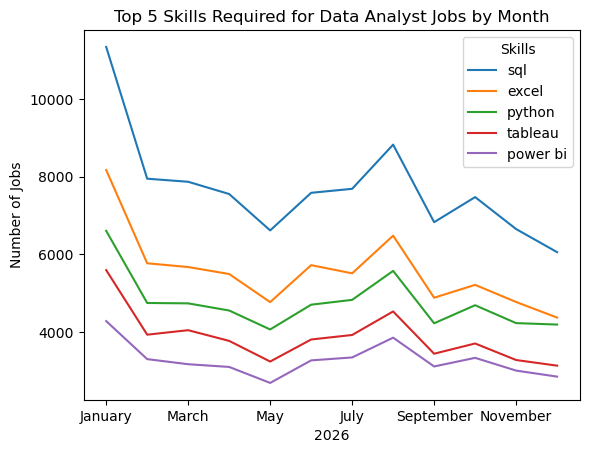

In [97]:
df_DA_pivot.plot(kind='line')
plt.title('Top 5 Skills Required for Data Analyst Jobs by Month')
plt.xlabel('2026')
plt.ylabel('Number of Jobs')
plt.legend(title='Skills')
plt.show()